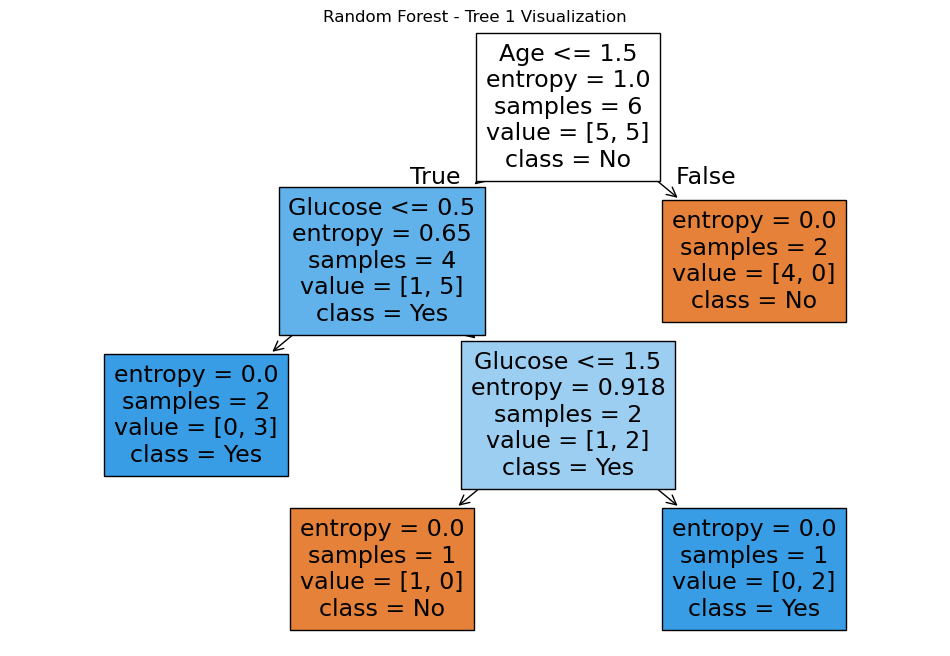

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Dataset
data = {
    'Glucose': ['High','High','Medium','Low','Low','Medium','High','Low','Medium','Low'],
    'BMI': ['High','Medium','High','Medium','Low','Medium','High','Medium','High','Low'],
    'Age': ['Old','Middle','Old','Young','Young','Middle','Middle','Old','Middle','Young'],
    'Diabetes': ['Yes','Yes','Yes','No','No','No','Yes','No','Yes','No']
}

df = pd.DataFrame(data)

# Encode
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df[['Glucose','BMI','Age']]
y = df['Diabetes']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=3, criterion='entropy', random_state=0)
rf.fit(X, y)

# Visualize the first tree
plt.figure(figsize=(12,8))
plot_tree(rf.estimators_[0],
          feature_names=['Glucose','BMI','Age'],
          class_names=['No','Yes'],
          filled=True)
plt.title("Random Forest - Tree 1 Visualization")
plt.show()


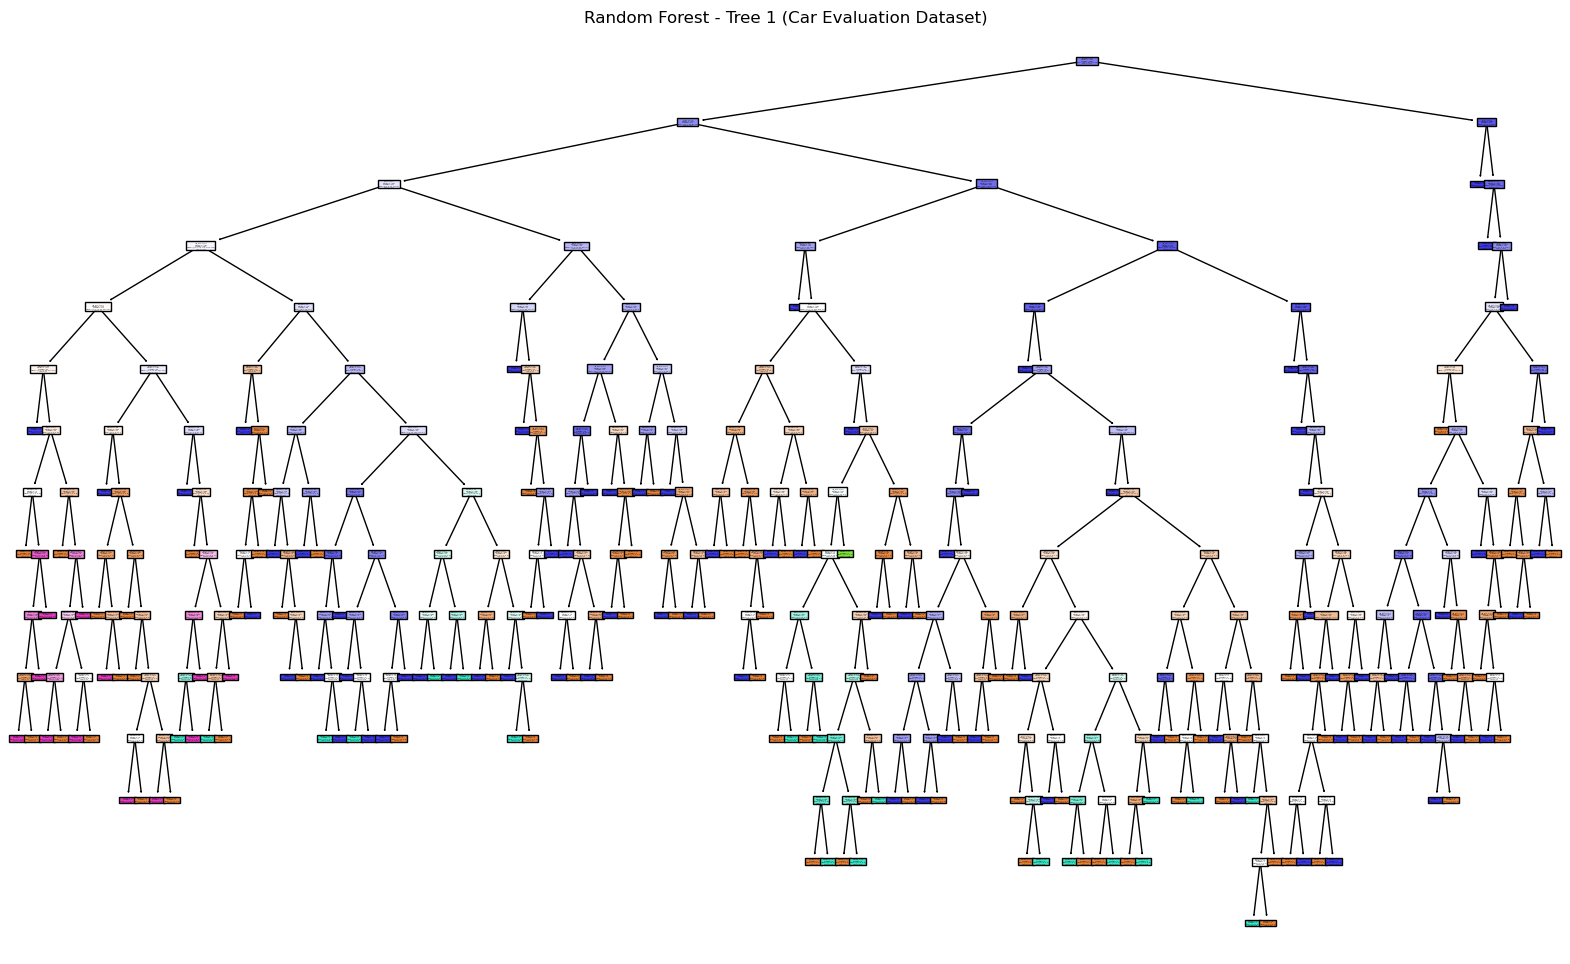

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Load Dataset Properly
# -----------------------------
df = pd.read_csv("datasets/car_evaluation.csv", header=None)

df.columns = ['buying','maint','doors','persons','lug_boot','safety','class']

# -----------------------------
# 2️⃣ Encode Categorical Data
# -----------------------------
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# -----------------------------
# 3️⃣ Separate Features & Target
# -----------------------------
X = df.drop("class", axis=1)
y = df["class"]

# -----------------------------
# 4️⃣ Train Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=3,
    criterion='entropy',
    random_state=0
)

rf.fit(X, y)

# -----------------------------
# 5️⃣ Visualize First Tree
# -----------------------------
plt.figure(figsize=(20,12))

plot_tree(rf.estimators_[0],
          feature_names=X.columns,
          class_names=encoders['class'].classes_,
          filled=True)

plt.title("Random Forest - Tree 1 (Car Evaluation Dataset)")
plt.show()


In [2]:
# -----------------------------
# 6️⃣ Predict Using User Input
# -----------------------------

print("\nEnter Car Details:")

buying = input("Buying price (vhigh/high/med/low): ").strip()
maint = input("Maintenance cost (vhigh/high/med/low): ").strip()
doors = input("Number of doors (2/3/4/5more): ").strip()
persons = input("Capacity (2/4/more): ").strip()
lug_boot = input("Luggage boot size (small/med/big): ").strip()
safety = input("Safety (low/med/high): ").strip()

# Create dataframe for input
user_data = pd.DataFrame([[buying, maint, doors, persons, lug_boot, safety]],
                         columns=['buying','maint','doors','persons','lug_boot','safety'])

# Encode input using trained encoders
for col in user_data.columns:
    user_data[col] = encoders[col].transform(user_data[col])

# Predict
prediction = rf.predict(user_data)

# Convert encoded output back to original label
final_prediction = encoders['class'].inverse_transform(prediction)

print("\nPredicted Car Evaluation:", final_prediction[0])



Enter Car Details:


Buying price (vhigh/high/med/low):  high
Maintenance cost (vhigh/high/med/low):  med
Number of doors (2/3/4/5more):  3
Capacity (2/4/more):  4
Luggage boot size (small/med/big):  big
Safety (low/med/high):  high



Predicted Car Evaluation: acc
